In [ ]:
import os
import time
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 69
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.14.0+cpu | device: cpu


## Task 1

### Task 1.1 Descarga y preprocesamiento

In [ ]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
if not os.path.exists("ETTh1.csv"):          # evita descargar de nuevo si ya existe
    urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

print(f"Observaciones horarias: {len(OT)}")
print(f"ALL shape: {ALL.shape}")
print(f"OT: min={OT.min():.3f}  max={OT.max():.3f}  media={OT.mean():.3f}")

Observaciones horarias: 17420  (~1.99 años)
ALL shape: (17420, 7)
OT: min=-4.080  max=46.007  media=13.325


#### a. Normalización z-score.

Cada valor se transforma como

$$\tilde{x}_t = \frac{x_t - \mu}{\sigma}$$

Se guardan `mu` y `sigma` para desnormalizar las predicciones a evaluar

In [3]:
# a. z-score: x_norm = (x - mu) / sigma
mu    = float(OT.mean())
sigma = float(OT.std())
OT_norm = torch.tensor((OT - mu) / sigma, dtype=torch.float32)


def denorm(z):
    # Inversa del z-score: x = z * sigma + mu  (regresa a grados Celsius)
    return z * sigma + mu


print(f"mu = {mu:.4f} °C   sigma = {sigma:.4f} °C")
print(f"OT_norm: media={OT_norm.mean().item():.2e}  std={OT_norm.std(unbiased=False).item():.4f}")

mu = 13.3247 °C   sigma = 8.5667 °C
OT_norm: media=-2.02e-08  std=1.0000


#### b. Split temporal contiguo

(60% / 20% / 20%), sin mezcla aleatoria: el modelo solo ve el pasado al entrenar y se evalúa en el futuro.

In [ ]:
# b. Split temporal: bloques contiguos [0, n_tr) | [n_tr, n_tr+n_vl) | [n_tr+n_vl, n)
n    = len(OT_norm)
n_tr = int(0.6 * n)
n_vl = int(0.2 * n)

OT_train = OT_norm[:n_tr]
OT_val   = OT_norm[n_tr:n_tr + n_vl]
OT_test  = OT_norm[n_tr + n_vl:]          # el resto (~20%)

print(f"train: {len(OT_train):>6}  ({len(OT_train)/n:.1%})  indices [0, {n_tr})")
print(f"val  : {len(OT_val):>6}  ({len(OT_val)/n:.1%})  indices [{n_tr}, {n_tr + n_vl})")
print(f"test : {len(OT_test):>6}  ({len(OT_test)/n:.1%})  indices [{n_tr + n_vl}, {n})")

train:  10452  (60.0%)  indices [0, 10452)
val  :   3484  (20.0%)  indices [10452, 13936)
test :   3484  (20.0%)  indices [13936, 17420)


#### c. Ventaneo

Para cada instante $t$ se construye el par

$$X^{(t)} = (x_{t-L+1}, \dots, x_t), \qquad y^{(t)} = x_{t+H}$$

El primer $t$ válido es $t = L-1$ (hay $L$ valores de historia) y el último es $t = N-1-H$ (existe el objetivo $x_{t+H}$), por lo que se obtienen $N - L - H + 1$ ejemplos por split.

In [ ]:
def make_windows(series, L, H):
    # Parametros
    # series : serie 1D (tensor o array) de longitud N
    # L: longitud de la ventana de historia
    # H: horizonte de prediccion
    #
    # Retorna
    # X: Tensor (N_w, L)  con X^(t) = (x_{t-L+1}, ..., x_t)
    # y: Tensor (N_w,)    con y^(t) = x_{t+H}
    series = torch.as_tensor(series, dtype=torch.float32)
    N = series.shape[0]
    N_w = N - L - H + 1
    assert N_w > 0, "La serie es demasiado corta para L y H dados"

    # unfold genera todas las ventanas deslizantes de largo L con paso 1:
    # la fila j es (x_j, ..., x_{j+L-1}), es decir, termina en t = j + L - 1
    X = series.unfold(0, L, 1)[:N_w].clone()
    # el objetivo de la fila j es x_{t+H} = x_{j+L-1+H}
    y = series[L - 1 + H: L - 1 + H + N_w].clone()
    return X, y

L = 96

# H = 24
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L, 24)
X_te_24, y_te_24 = make_windows(OT_test,  L, 24)

# H = 48
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L, 48)
X_te_48, y_te_48 = make_windows(OT_test,  L, 48)

for H, (Xtr, Xvl, Xte) in {24: (X_tr_24, X_vl_24, X_te_24),
                           48: (X_tr_48, X_vl_48, X_te_48)}.items():
    print(f"H={H}: X_tr {tuple(Xtr.shape)} | X_vl {tuple(Xvl.shape)} | X_te {tuple(Xte.shape)}")

t = L - 1
assert torch.equal(X_tr_24[0], OT_train[t - L + 1: t + 1])
assert y_tr_24[0] == OT_train[t + 24]

H=24: X_tr (10333, 96) | X_vl (3365, 96) | X_te (3365, 96)
H=48: X_tr (10309, 96) | X_vl (3341, 96) | X_te (3341, 96)


Baseline naive (persistencia). Predice que el valor dentro de $H$ horas será igual al último observado: $\hat{y}^{(t)} = x_t$ = `X[:, -1]`. Sirve como referencia: un modelo útil debe tener ratio `MAE_modelo / MAE_naive` < 1.

In [6]:
def naive_metrics(X, y):
    # Persistencia: y_hat = x_t (ultimo valor de la ventana)
    y_hat = X[:, -1]
    mae  = torch.abs(y - y_hat).mean().item()
    rmse = torch.sqrt(((y - y_hat) ** 2).mean()).item()
    return mae, rmse


for H, (Xv, yv) in {24: (X_vl_24, y_vl_24), 48: (X_vl_48, y_vl_48)}.items():
    mae, rmse = naive_metrics(Xv, yv)
    print(f"Naive val H={H}: MAE={mae:.4f} (norm) = {mae * sigma:.3f} °C | "
          f"RMSE={rmse:.4f} (norm) = {rmse * sigma:.3f} °C")

Naive val H=24: MAE=0.1996 (norm) = 1.710 °C | RMSE=0.2672 (norm) = 2.289 °C
Naive val H=48: MAE=0.2604 (norm) = 2.231 °C | RMSE=0.3359 (norm) = 2.878 °C


### Task 1.2 Función de autocorrelación (ACF)

#### a. ACF manual:

El numerador es la autocovarianza al lag $k$ (promediada sobre los $N-k$ pares disponibles) y el denominador es la varianza (autocovarianza al lag 0), por lo que $\rho(0) = 1$.

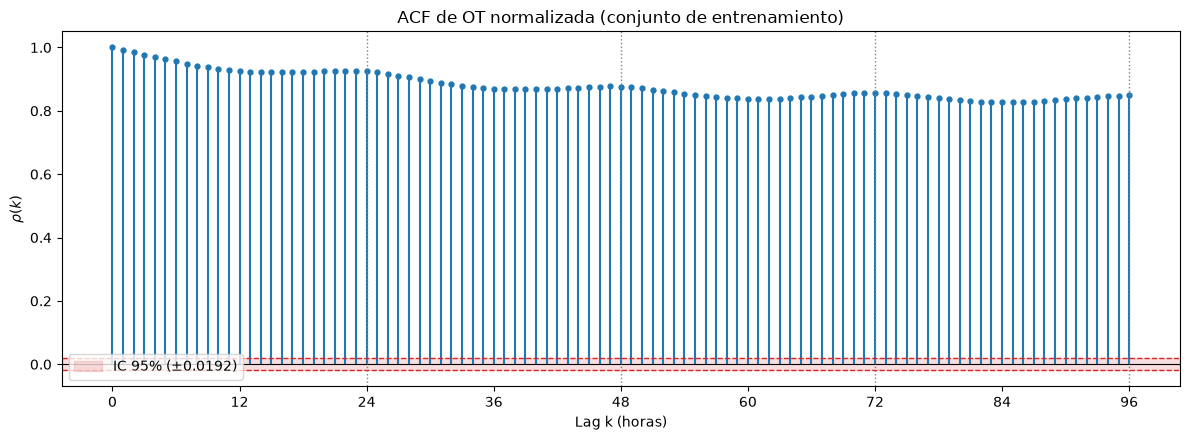

N = 10452,  banda 95% = ±0.0192
rho(k) en lags clave:
  k= 1: 0.9923
  k= 6: 0.9558
  k=12: 0.9250
  k=18: 0.9228
  k=24: 0.9250
  k=36: 0.8695
  k=48: 0.8763
  k=72: 0.8572
  k=96: 0.8489
Lags significativos (|rho| > banda): 96 de 96


In [ ]:
def acf_manual(series, max_lag):
    # Calcula rho(k) para k = 0, 1, ..., max_lag segun la formula de la celda anterior
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    x_bar = x.mean()
    d = x - x_bar # (x_t - x_bar)

    gamma0 = (d ** 2).sum() / N # denominador: (1/N) sum (x_t - x_bar)^2

    acf = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        # numerador: (1/(N-k)) sum_{t=k}^{N-1} (x_t - x_bar)(x_{t-k} - x_bar)
        # d[k:] recorre x_t con t = k..N-1  y  d[:N-k] recorre x_{t-k}
        gamma_k = (d[k:] * d[:N - k]).sum() / (N - k)
        acf[k] = gamma_k / gamma0
    return acf


max_lag = 96
acf_train = acf_manual(OT_train.numpy(), max_lag)
N_acf = len(OT_train)
conf = 1.96 / np.sqrt(N_acf) # banda de confianza al 95%: +-1.96/sqrt(N)

fig, ax = plt.subplots(figsize=(12, 4.5))
lags = np.arange(max_lag + 1)
ax.vlines(lags, 0, acf_train, color="tab:blue", lw=1.5)
ax.plot(lags, acf_train, "o", color="tab:blue", ms=3.5)
ax.axhline(0, color="black", lw=0.8)
ax.axhspan(-conf, conf, color="tab:red", alpha=0.15, label=f"IC 95% (±{conf:.4f})")
ax.axhline(conf, color="tab:red", ls="--", lw=1)
ax.axhline(-conf, color="tab:red", ls="--", lw=1)
for k in (24, 48, 72, 96):
    ax.axvline(k, color="gray", ls=":", lw=1)
ax.set_xticks(range(0, max_lag + 1, 12))
ax.set_xlabel("Lag k (horas)")
ax.set_ylabel(r"$\rho(k)$")
ax.set_title("ACF de OT normalizada (conjunto de entrenamiento)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"N = {N_acf},  banda 95% = ±{conf:.4f}")
print("rho(k) en lags clave:")
for k in (1, 6, 12, 18, 24, 36, 48, 72, 96):
    print(f"  k={k:>2}: {acf_train[k]:.4f}")
print(f"Lags significativos (|rho| > banda): {(np.abs(acf_train[1:]) > conf).sum()} de {max_lag}")

In [8]:
# Picos de la ACF: maximos locales rho(k-1) < rho(k) > rho(k+1), excluyendo lag 0
peaks = [k for k in range(1, max_lag) if acf_train[k] > acf_train[k - 1] and acf_train[k] > acf_train[k + 1]]
peaks_sorted = sorted(peaks, key=lambda k: acf_train[k], reverse=True)

print("Maximos locales de la ACF (ordenados por rho):")
for k in peaks_sorted:
    print(f"  lag {k:>2}: rho = {acf_train[k]:.4f}")

second_peak = peaks_sorted[0]
print(f"\nSegundo pico mas alto (despues de lag 0): lag {second_peak}, rho = {acf_train[second_peak]:.4f}")

# Valles (minimos locales) para cuantificar la oscilacion diaria
troughs = [k for k in range(1, max_lag) if acf_train[k] < acf_train[k - 1] and acf_train[k] < acf_train[k + 1]]
print("Minimos locales:", [(k, round(float(acf_train[k]), 4)) for k in troughs])

Maximos locales de la ACF (ordenados por rho):
  lag 22: rho = 0.9262
  lag 47: rho = 0.8770
  lag 72: rho = 0.8572

Segundo pico mas alto (despues de lag 0): lag 22, rho = 0.9262
Minimos locales: [(15, 0.9211), (38, 0.8675), (61, 0.837), (84, 0.8266)]


### Verificación Task 1

In [9]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


## Task 2

### Task 2.1 `LSTMForecaster` implementado paso a paso

In [10]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        # Pesos de las 4 compuertas apilados en el orden [i, f, g, o]:
        #   Wx: (4*d_h, d_in)  -> termino W_x x_t
        #   Wh: (4*d_h, d_h)   -> termino W_h h_{t-1}
        #   b : (4*d_h,)       -> sesgo de las compuertas
        # Inicializacion uniforme U(-1/sqrt(d_h), 1/sqrt(d_h)), la misma que usa PyTorch para LSTM
        k = 1.0 / d_h ** 0.5
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-k, k))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-k, k))
        b = torch.empty(4 * d_h).uniform_(-k, k)
        # Sesgo de la forget gate en 1: al inicio f_t ~ sigma(1) ~ 0.73, la celda "recuerda" por defecto
        # y el gradiente fluye mejor a traves de c_t (dc_t/dc_{t-1} = f_t)
        b[d_h:2 * d_h] = 1.0
        self.b = nn.Parameter(b)
        # Capa de salida: y_hat = W_out h_L + b_out
        self.W_out = nn.Parameter(torch.empty(1, d_h).uniform_(-k, k))
        self.b_out = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        '''
        Parametros
        ----------
        x : Tensor (B, L): batch de secuencias univariadas

        Retorna
        -------
        pred : Tensor (B,): prediccion escalar por secuencia
        '''
        B, L = x.shape
        d_h = self.d_h
        # 1. (B, L) -> (B, L, 1): cada paso temporal es un vector de d_in = 1
        x = x.unsqueeze(-1)
        # 2. Estados iniciales h_0 = c_0 = 0, forma (B, d_h)
        h = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)
        c = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)
        # El termino W_x x_t no depende de h, asi que se precalcula para todos los t a la vez
        # (mismo resultado que hacerlo dentro del loop, pero mas rapido): (B, L, 4*d_h)
        x_proj = x @ self.Wx.T
        # 3. Recurrencia paso a paso
        for t in range(L):
            # a. gates = x_t W_x^T + h_{t-1} W_h^T + b   -> (B, 4*d_h)
            gates = x_proj[:, t, :] + h @ self.Wh.T + self.b
            # b. separar en las 4 compuertas de dimension d_h
            a_i, a_f, a_g, a_o = gates.chunk(4, dim=-1)
            # c. no linealidades: sigmoide para i, f, o (valores en (0,1)); tanh para g (en (-1,1))
            i = torch.sigmoid(a_i)
            f = torch.sigmoid(a_f)
            g = torch.tanh(a_g)
            o = torch.sigmoid(a_o)
            # d. estado de celda: c_t = f_t * c_{t-1} + i_t * g_t
            c = f * c + i * g
            # e. estado oculto: h_t = o_t * tanh(c_t)
            h = o * torch.tanh(c)
        # 4. many-to-one: se proyecta solo h_L -> y_hat = h_L W_out^T + b_out, forma (B, 1)
        pred = h @ self.W_out.T + self.b_out
        # 5. (B, 1) -> (B,)
        return pred.squeeze(-1)


_m = LSTMForecaster(d_in=1, d_h=32)
print(_m(torch.randn(3, 96)).shape, "| parametros:", sum(p.numel() for p in _m.parameters()))

torch.Size([3]) | parametros: 4385


### Task 2.2 Entrenamiento

**Función de pérdida: MSE** (error cuadrático medio)

$$\mathcal{L} = \frac{1}{B}\sum_{b=1}^{B}\left(y^{(b)} - \hat{y}^{(b)}\right)^2$$

#### Cambio de distribución entre train y validación

Antes de entrenar conviene comparar los splits. El split temporal hace que train (primeros ~14 meses) y validación (siguientes ~5 meses) tengan niveles de temperatura muy distintos:

In [11]:
for name, s in [("train", OT_train), ("val", OT_val), ("test", OT_test)]:
    print(f"{name:<5}: media={s.mean().item():+.3f}  std={s.std().item():.3f}  "
          f"min={s.min().item():+.3f}  max={s.max().item():+.3f}   (escala normalizada)")

train: media=+0.463  std=0.994  min=-2.032  max=+3.815   (escala normalizada)
val  : media=-0.735  std=0.513  min=-1.991  max=+0.736   (escala normalizada)
test : media=-0.654  std=0.402  min=-1.662  max=+0.448   (escala normalizada)


#### a. forecast

In [12]:
EPOCHS     = 20
BATCH_SIZE = 64
LR         = 1e-3


def forecast(model, X):
    # y_hat = x_t + LSTM(X - x_t): la ventana se referencia a su ultimo valor x_t = X[:, -1]
    last = X[:, -1:]                               # (B, 1)
    return model(X - last) + last.squeeze(-1)      # (B,)


def train_model(model, X_tr, y_tr, X_vl, y_vl, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, tag=""):
    # Entrena con Adam minimizando MSE. Retorna historiales de perdida (train por epoca y val por epoca)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()                         # L = mean((y - y_hat)^2)
    N = X_tr.shape[0]
    hist_tr, hist_vl = [], []
    for ep in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        perm = torch.randperm(N)                   # barajar ejemplos (ventanas), no la serie
        running = 0.0
        for s in range(0, N, batch_size):
            idx = perm[s:s + batch_size]
            xb, yb = X_tr[idx].to(device), y_tr[idx].to(device)
            opt.zero_grad()
            loss = loss_fn(forecast(model, xb), yb)   # MSE(y, x_t + LSTM(X - x_t))
            loss.backward()                        # BPTT a traves de los L pasos
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item() * xb.shape[0]
        hist_tr.append(running / N)                # MSE promedio de la epoca

        model.eval()
        with torch.no_grad():
            vl_loss = loss_fn(predict(model, X_vl), y_vl).item()
        hist_vl.append(vl_loss)
        print(f"[{tag}] epoca {ep:>2}/{epochs}  train MSE={hist_tr[-1]:.5f}  "
              f"val MSE={vl_loss:.5f}  ({time.time() - t0:.1f}s)")
    return hist_tr, hist_vl


@torch.no_grad()
def predict(model, X, batch_size=1024):
    # Predicciones y_hat = x_t + LSTM(X - x_t) en lotes grandes, devueltas en CPU
    model.eval()
    return torch.cat([forecast(model, X[s:s + batch_size].to(device)).cpu() for s in range(0, X.shape[0], batch_size)])

#### b.

Se entrenan dos modelos `LSTMForecaster(d_in=1, d_h=32)`, uno por horizonte, sobre el mismo conjunto de entrenamiento.

In [13]:
torch.manual_seed(SEED)
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
hist_tr_24, hist_vl_24 = train_model(lstm_24, X_tr_24, y_tr_24, X_vl_24, y_vl_24, tag="LSTM H=24")

[LSTM H=24] epoca  1/20  train MSE=0.14392  val MSE=0.06760  (4.7s)


[LSTM H=24] epoca  2/20  train MSE=0.14073  val MSE=0.06864  (4.8s)


[LSTM H=24] epoca  3/20  train MSE=0.13932  val MSE=0.06661  (4.6s)


[LSTM H=24] epoca  4/20  train MSE=0.13892  val MSE=0.07236  (4.6s)


[LSTM H=24] epoca  5/20  train MSE=0.14026  val MSE=0.06734  (4.7s)


...

[LSTM H=24] epoca 16/20  train MSE=0.13497  val MSE=0.06834  (4.8s)


[LSTM H=24] epoca 17/20  train MSE=0.13511  val MSE=0.06717  (4.6s)


[LSTM H=24] epoca 18/20  train MSE=0.13549  val MSE=0.06871  (4.7s)


[LSTM H=24] epoca 19/20  train MSE=0.13564  val MSE=0.06717  (4.6s)


[LSTM H=24] epoca 20/20  train MSE=0.13569  val MSE=0.06834  (4.7s)


In [14]:
torch.manual_seed(SEED)
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
hist_tr_48, hist_vl_48 = train_model(lstm_48, X_tr_48, y_tr_48, X_vl_48, y_vl_48, tag="LSTM H=48")

[LSTM H=48] epoca  1/20  train MSE=0.22732  val MSE=0.10557  (4.7s)


[LSTM H=48] epoca  2/20  train MSE=0.21883  val MSE=0.10957  (4.5s)


[LSTM H=48] epoca  3/20  train MSE=0.22546  val MSE=0.09869  (4.6s)


[LSTM H=48] epoca  4/20  train MSE=0.21528  val MSE=0.10543  (4.7s)


[LSTM H=48] epoca  5/20  train MSE=0.21873  val MSE=0.10228  (4.7s)


...

[LSTM H=48] epoca 16/20  train MSE=0.19233  val MSE=0.09767  (4.4s)


[LSTM H=48] epoca 17/20  train MSE=0.19116  val MSE=0.09919  (4.5s)


[LSTM H=48] epoca 18/20  train MSE=0.19174  val MSE=0.09761  (4.5s)


[LSTM H=48] epoca 19/20  train MSE=0.19039  val MSE=0.10176  (4.6s)


[LSTM H=48] epoca 20/20  train MSE=0.19061  val MSE=0.10126  (4.2s)


**c. Métricas en validación.**

$$\text{MAE} = \frac{1}{N}\sum |y - \hat{y}|, \qquad \text{RMSE} = \sqrt{\frac{1}{N}\sum (y - \hat{y})^2}, \qquad \text{ratio} = \frac{\text{MAE}_{modelo}}{\text{MAE}_{naive}}$$

Se reportan en escala normalizada y desnormalizada (°C, usando `mu` y `sigma`). El ratio es igual en ambas escalas porque el factor $\sigma$ se cancela.

In [15]:
pred_vl_24 = predict(lstm_24, X_vl_24)
pred_vl_48 = predict(lstm_48, X_vl_48)


def metrics(y, y_hat):
    mae  = torch.abs(y - y_hat).mean().item()
    rmse = torch.sqrt(((y - y_hat) ** 2).mean()).item()
    return mae, rmse


results = {}
for H, (Xv, yv, pv) in {24: (X_vl_24, y_vl_24, pred_vl_24),
                        48: (X_vl_48, y_vl_48, pred_vl_48)}.items():
    mae_n, rmse_n = naive_metrics(Xv, yv)
    # Metricas en °C: se desnormaliza y y y_hat (equivale a multiplicar el error por sigma)
    mae_c,  rmse_c  = metrics(denorm(yv), denorm(pv))
    mae_nc, rmse_nc = metrics(denorm(yv), denorm(Xv[:, -1]))
    mae_m, rmse_m = metrics(yv, pv)
    results[H] = dict(mae=mae_m, rmse=rmse_m, mae_c=mae_c, rmse_c=rmse_c,
                      naive_mae=mae_n, naive_rmse=rmse_n, naive_mae_c=mae_nc, naive_rmse_c=rmse_nc,
                      ratio=mae_m / mae_n)

header = f"{'Modelo':<7}{'H':>4} | {'MAE (norm)':>10} {'RMSE (norm)':>11} | {'MAE (°C)':>9} {'RMSE (°C)':>9} | {'Ratio vs naive':>14}"
print(header)
print("-" * len(header))
for H, r in results.items():
    print(f"{'LSTM':<7}{H:>4} | {r['mae']:>10.4f} {r['rmse']:>11.4f} | {r['mae_c']:>9.3f} {r['rmse_c']:>9.3f} | {r['ratio']:>14.3f}")
for H, r in results.items():
    print(f"{'Naive':<7}{H:>4} | {r['naive_mae']:>10.4f} {r['naive_rmse']:>11.4f} | {r['naive_mae_c']:>9.3f} {r['naive_rmse_c']:>9.3f} | {1.0:>14.3f}")

Modelo    H | MAE (norm) RMSE (norm) |  MAE (°C) RMSE (°C) | Ratio vs naive
---------------------------------------------------------------------------
LSTM     24 |     0.2015      0.2614 |     1.727     2.240 |          1.010
LSTM     48 |     0.2554      0.3182 |     2.188     2.726 |          0.981
Naive    24 |     0.1996      0.2672 |     1.710     2.289 |          1.000
Naive    48 |     0.2604      0.3359 |     2.231     2.878 |          1.000


#### d. Curvas de pérdida de entrenamiento

para ambos horizontes en la misma figura.

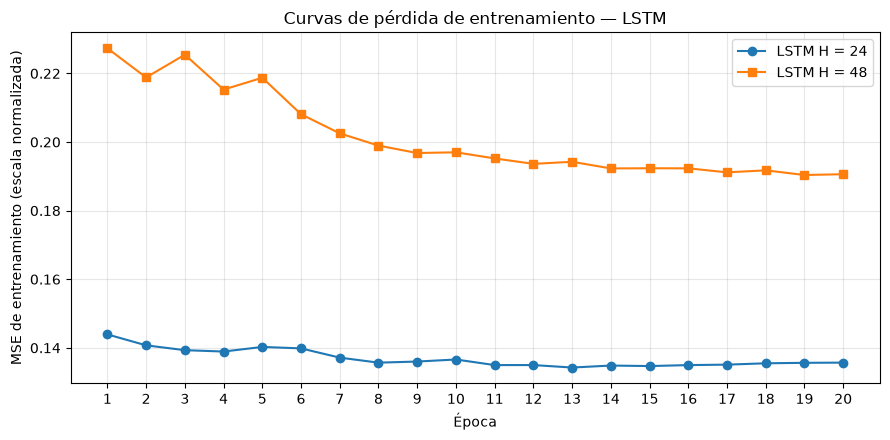

In [16]:
epochs_ax = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(epochs_ax, hist_tr_24, "o-", label="LSTM H = 24")
ax.plot(epochs_ax, hist_tr_48, "s-", label="LSTM H = 48")
ax.set_xlabel("Época")
ax.set_ylabel("MSE de entrenamiento (escala normalizada)")
ax.set_title("Curvas de pérdida de entrenamiento — LSTM")
ax.set_xticks(epochs_ax)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

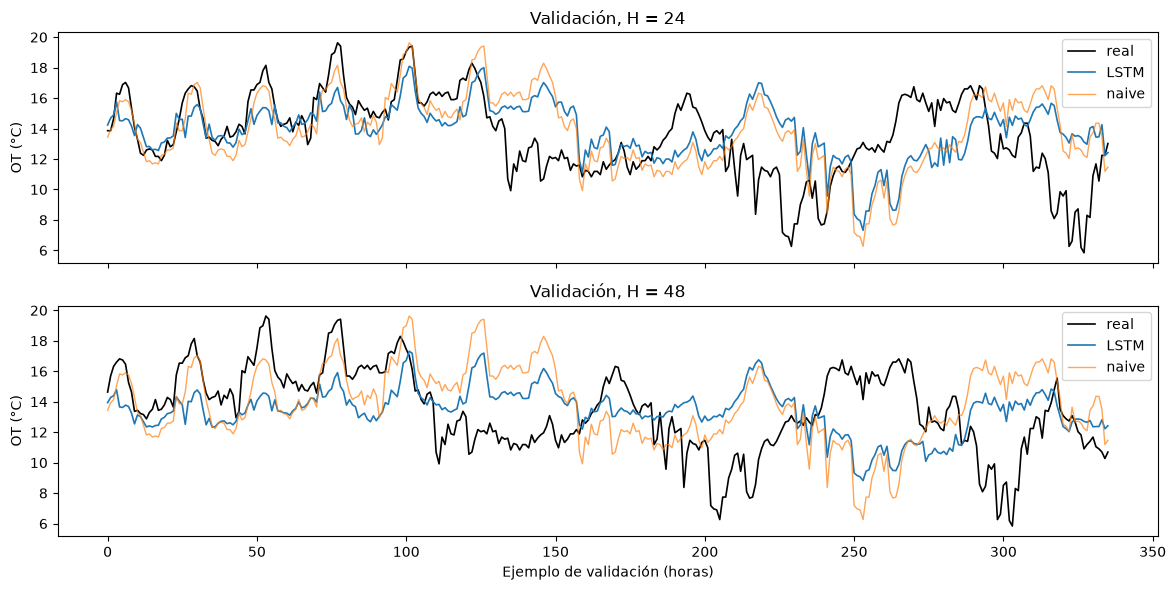

In [17]:
# Visualizacion complementaria: prediccion vs real en un tramo de validacion (en °C)
n_show = 24 * 14   # dos semanas
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (H, yv, pv, Xv) in zip(axes, [(24, y_vl_24, pred_vl_24, X_vl_24), (48, y_vl_48, pred_vl_48, X_vl_48)]):
    ax.plot(denorm(yv[:n_show]).numpy(), label="real", color="black", lw=1.2)
    ax.plot(denorm(pv[:n_show]).numpy(), label="LSTM", color="tab:blue", lw=1.2)
    ax.plot(denorm(Xv[:n_show, -1]).numpy(), label="naive", color="tab:orange", lw=1, alpha=0.7)
    ax.set_title(f"Validación, H = {H}")
    ax.set_ylabel("OT (°C)")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Ejemplo de validación (horas)")
plt.tight_layout()
plt.show()

### Verificación Task 2

In [18]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.2015, ratio=1.010
